In [ ]:
# Внимание!!! Важно, что бы файлы с данными и исполняемый файл находились в одной папке, 
# тогда пути к тестовым и тренировочным наборам будут содержать только имена файлов.
# 
# В пути к тренировочным и тестовым данным запрежается использовать абсалютную адресацию, 
# то есть адресацию, в которой присутствуют имена папок. Путь должен содержать только имя файла.
#
# Напоминание: под моделью машинного обучения понимаются все действия с исходными данными, 
# которые необходимо произвести, что бы сопоставить признаки целевому значению.

### Область работы 1 (библиотеки)

In [1]:
# Данный блок в области 1 НЕ выполняется преподавателем
# 
# данный блок предназначен только для подключения необходимых библиотек
# запрещается подключать библиотеки в других блоках
#
# установка дополнительных библиотек размещается прямо здесь (обязательно закоментированы)
#
# pip install

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.neighbors import KNeighborsClassifier 


from sklearn.preprocessing import OrdinalEncoder,LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.compose import make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, PowerTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
import category_encoders as ce
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
import sklearn


### Область работы 2 (поиск  модели .... )

In [3]:
# Данный блок(и) НЕ выполняются преподавателем в области 2
# блок(и) предназначены для поиска лучшей модели 
# должен быть понятен и очевиден отбор параметров модели
# 
# Запрещается размещать данные блоки за пределами обасти 2
# Все блоки данной области должны быть выполнены
#
# ЗАПРЕЩАЕТСЯ ИСПОЛЬЗОВАТЬ ТЕСТОВЫЙ НАБОР
#
# Путь к тренировочному набору
# 

path_train = 'train.csv'
path_test = 'test.csv'
df=pd.read_csv(path_train)
df

,size,color,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,clarity,cut,symmetry,polish,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,culet_condition,fluor_color,fluor_intensity,total_sales_price,eye_clean
0,0.76,D,NaN,NaN,NaN,NaN,I1,Excellent,Excellent,Excellent,...,6.02,6.04,3.55,TN,M,NaN,NaN,NaN,3712,NaN
1,1.00,H,NaN,NaN,NaN,NaN,VVS1,Very Good,Excellent,Excellent,...,6.27,6.32,4.03,STK,TK,NaN,NaN,NaN,9717,NaN
2,0.30,F,NaN,NaN,NaN,NaN,VS1,Very Good,Very Good,Very Good,...,4.33,4.36,2.60,XTN,M,NaN,NaN,NaN,954,NaN
3,0.30,D,NaN,NaN,NaN,NaN,SI1,Excellent,Very Good,Excellent,...,4.24,4.29,2.67,STK,STK,NaN,NaN,Faint,858,NaN
4,0.32,F,NaN,NaN,NaN,NaN,VS1,Excellent,Excellent,Excellent,...,4.39,4.40,2.73,M,STK,NaN,NaN,NaN,1150,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61440,0.40,D,NaN,NaN,NaN,NaN,SI2,Excellent,Excellent,Excellent,...,4.67,4.71,2.95,NaN,NaN,NaN,NaN,Faint,1188,NaN
61441,0.30,D,NaN,NaN,NaN,NaN,VVS2,Excellent,Excellent,Excellent,...,4.27,4.30,2.64,M,STK,NaN,Blue,Medium,992,Yes
61442,0.32,G,NaN,NaN,NaN,NaN,VS2,Excellent,Excellent,Excellent,...,4.42,4.44,2.68,M,TK,NaN,Blue,Medium,1008,NaN
61443,0.60,H,NaN,NaN,NaN,NaN,VS2,Excellent,Excellent,Excellent,...,5.35,5.37,3.39,NaN,NaN,NaN,NaN,NaN,3730,NaN


**size** - вес в каратах  
**color** - оценка отсутствия цвета у белого бриллианта. Шкала от D (самый лучший, абсолютно бесцветный) до M (заметный желтый или коричневый оттенок). D, E, F, G, H, I, J, K, L, M  
**clarity** (Чистота) - Оценка количества и видимости внутренних включений и внешних дефектов. Допустимые значения (от лучшего к худшему):'IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1', 'I2', 'I3'.  
**fancy_color_dominant_color** - Основной, наиболее выраженный цвет бриллианта (фантазийный цвет, например голубой, розовый итд.)    
**fancy_color_secondary_color** - Второй цвет, который присутствует в бриллианте наряду с основным.  
**fancy_color_overtone** - Дополнительный оттенок, который накладывается на основной цвет.  
**fancy_color_intensity** - Интенсивность фантазийного цвета.  
**cut** - Качество огранки ('Excellent' 'Very Good')  
**symmetry** - Симметрия, то есть насколько симметричны и точно выровнены все грани бриллианта ('Excellent' 'Very Good')  
**polish** - Полировка('Excellent' 'Very Good')  
**depth_percent** - Процент глубины. Допустимые значения: Обычно от 55% до 75%.  
**table_percent** - Процент площадки. Допустимые значения: Обычно от 50% до 70%.  
**meas_length** - Длина в мм  
**meas_width** - Ширина в мм. Для круглой огранки в идеале length и width должны быть почти равны.  
**meas_depth** - Глубина в мм  
**girdle_min** - Минимальная толщина рундиста. Рундист это край бриллианта, разделяющий верхнюю и нижнюю части. Описывается толщиной от тонкого к толстому ('XTN', 'VTN', 'TN', 'STN', 'M', 'STK', 'TK', 'VTK')  
**girdle_max** -  Максимальная толщина рундиста ('XTN', 'VTN', 'TN', 'STN', 'M', 'STK', 'TK', 'VTK', 'XTK').  
**culet_condition** - Калетта: Маленькая грань в самом низу бриллианта (есть калетта -'Chipped'). В современной огранке часто отсутствует, это обозначается как'Pointed'.  
**fluor_color** - Цвет флуоресценции ('Yellow' 'Blue' 'Green' 'White' 'Orange').  
**fluor_intensity** - Интенсивность флуоресценции от низкой к высокой ('Very Slight', 'Faint', 'Medium', 'Strong', 'Very Strong').  
**eye_clean** - Субъективная оценка того, видимы ли включения в бриллианте невооруженным глазом без использования увеличительных приборов ('Yes' 'E1' 'Borderline' 'No') 'Borderline' и 'E1' - пограничные случаи.  
**total_sales_price** - Цена брильянта (целевая переменная)

In [4]:
df = df.drop_duplicates()


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61445 entries, 0 to 61444
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   size                         61445 non-null  float64
 1   color                        61445 non-null  object 
 2   fancy_color_dominant_color   0 non-null      float64
 3   fancy_color_secondary_color  0 non-null      float64
 4   fancy_color_overtone         0 non-null      float64
 5   fancy_color_intensity        0 non-null      float64
 6   clarity                      61445 non-null  object 
 7   cut                          61445 non-null  object 
 8   symmetry                     61445 non-null  object 
 9   polish                       61445 non-null  object 
 10  depth_percent                61445 non-null  float64
 11  table_percent                61445 non-null  float64
 12  meas_length                  61445 non-null  float64
 13  meas_width      

In [6]:
df.describe()

,size,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,depth_percent,table_percent,meas_length,meas_width,meas_depth,total_sales_price
count,61445.000000,0.0,0.0,0.0,0.0,61445.000000,61445.000000,61445.000000,61445.0000,61445.000000,61445.000000
mean,0.480407,NaN,NaN,NaN,NaN,62.101587,57.799370,4.857504,4.8888,3.026854,2524.963561
std,0.262129,NaN,NaN,NaN,NaN,1.302779,1.809108,0.793800,0.7988,0.497674,2959.193410
min,0.150000,NaN,NaN,NaN,NaN,56.000000,50.000000,3.390000,3.4200,2.100000,264.000000
25%,0.300000,NaN,NaN,NaN,NaN,61.400000,56.000000,4.290000,4.3100,2.680000,892.000000
50%,0.370000,NaN,NaN,NaN,NaN,62.300000,58.000000,4.580000,4.6100,2.850000,1208.000000
75%,0.550000,NaN,NaN,NaN,NaN,62.800000,59.000000,5.230000,5.2600,3.250000,3024.000000
max,1.490000,NaN,NaN,NaN,NaN,66.500000,67.000000,7.430000,7.5300,4.500000,31133.000000


In [7]:
missing_info = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Пропуски': df.isnull().sum(),
    'Процент пропусков': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_info)

                            Тип данных  Пропуски  Процент пропусков
size                           float64         0               0.00
color                           object         0               0.00
fancy_color_dominant_color     float64     61445             100.00
fancy_color_secondary_color    float64     61445             100.00
fancy_color_overtone           float64     61445             100.00
fancy_color_intensity          float64     61445             100.00
clarity                         object         0               0.00
cut                             object         0               0.00
symmetry                        object         0               0.00
polish                          object         0               0.00
depth_percent                  float64         0               0.00
table_percent                  float64         0               0.00
meas_length                    float64         0               0.00
meas_width                     float64         0

Я думаю что стоит удалить колонки fancy_color_dominant_color, fancy_color_secondary_color, fancy_color_overtone и fancy_color_intensity, так как эти колонки заполняются только в случае цветных брильянтов, а в этом датасете все брильянты бесцветные и для них эти колонки никакой информации не несут. Еще удалю колонку culet_condition так как в ней большое количество пропусков (95.76 %) и она практически не несет никакой полезной информации для большей части датасета.

In [8]:
columns_to_drop = [
    'fancy_color_dominant_color', 
    'fancy_color_secondary_color', 
    'fancy_color_overtone', 
    'fancy_color_intensity',
    'culet_condition'
]
df = df.drop(columns=columns_to_drop)
df

,size,color,clarity,cut,symmetry,polish,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,total_sales_price,eye_clean
0,0.76,D,I1,Excellent,Excellent,Excellent,58.9,60.0,6.02,6.04,3.55,TN,M,NaN,NaN,3712,NaN
1,1.00,H,VVS1,Very Good,Excellent,Excellent,63.9,58.0,6.27,6.32,4.03,STK,TK,NaN,NaN,9717,NaN
2,0.30,F,VS1,Very Good,Very Good,Very Good,59.9,59.0,4.33,4.36,2.60,XTN,M,NaN,NaN,954,NaN
3,0.30,D,SI1,Excellent,Very Good,Excellent,62.7,58.0,4.24,4.29,2.67,STK,STK,NaN,Faint,858,NaN
4,0.32,F,VS1,Excellent,Excellent,Excellent,62.0,59.0,4.39,4.40,2.73,M,STK,NaN,NaN,1150,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61440,0.40,D,SI2,Excellent,Excellent,Excellent,62.9,56.0,4.67,4.71,2.95,NaN,NaN,NaN,Faint,1188,NaN
61441,0.30,D,VVS2,Excellent,Excellent,Excellent,61.7,61.0,4.27,4.30,2.64,M,STK,Blue,Medium,992,Yes
61442,0.32,G,VS2,Excellent,Excellent,Excellent,60.4,57.0,4.42,4.44,2.68,M,TK,Blue,Medium,1008,NaN
61443,0.60,H,VS2,Excellent,Excellent,Excellent,63.2,55.0,5.35,5.37,3.39,NaN,NaN,NaN,NaN,3730,NaN


In [9]:
y = np.array(df.total_sales_price)
X = df.drop(columns=['total_sales_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

array(['size', 'depth_percent', 'table_percent', 'meas_length',
       'meas_width', 'meas_depth'], dtype=object)

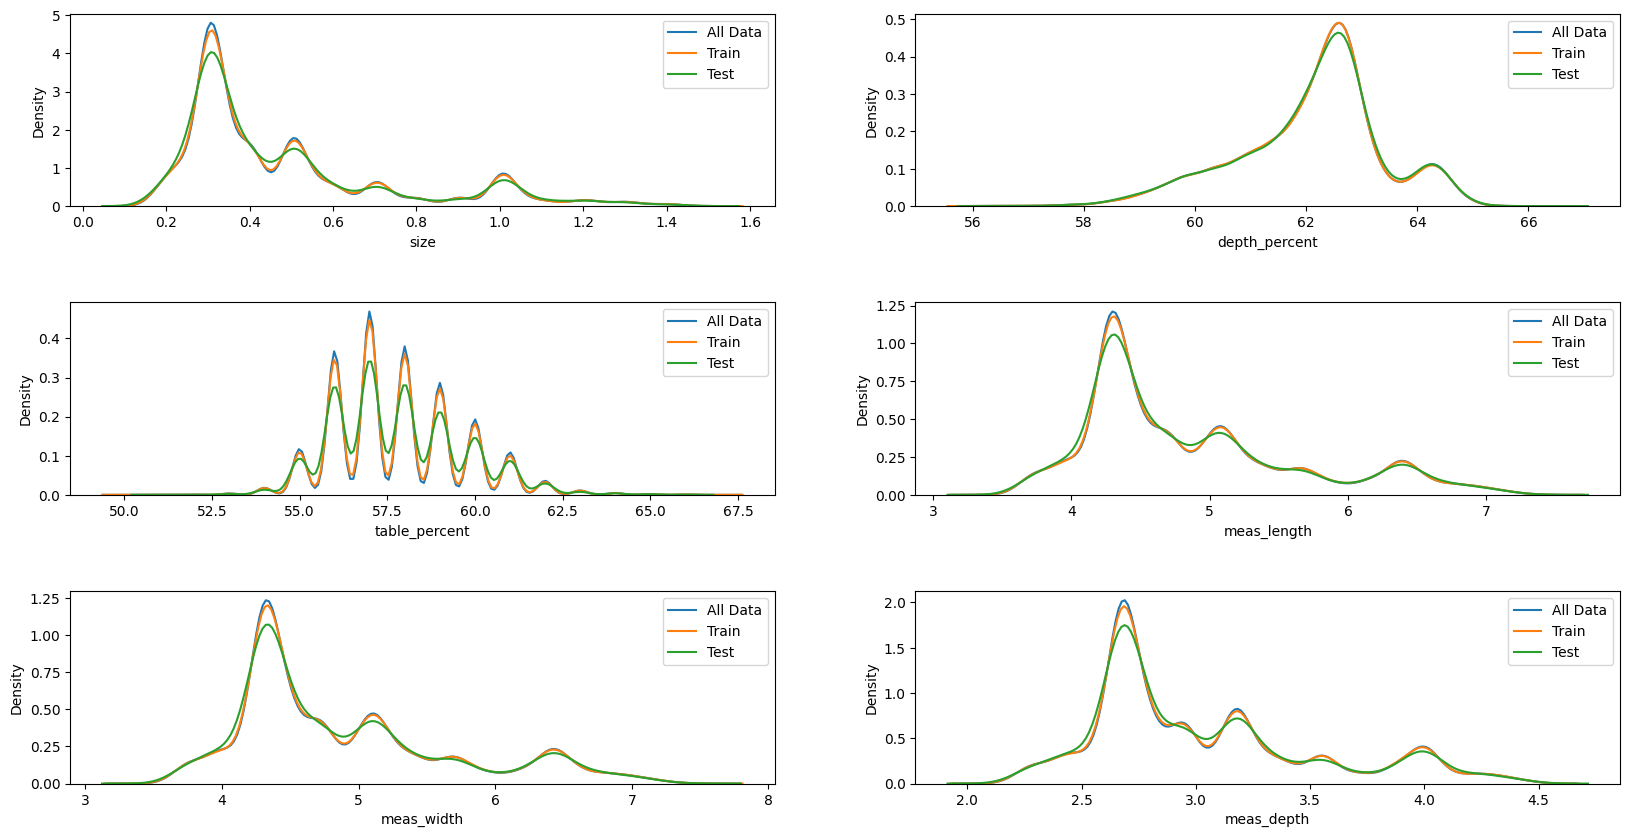

In [10]:
list_columns_number = X_test.select_dtypes(include=['number']).columns.values
display(list_columns_number)
fig, ax = plt.subplots(3, 2, figsize=(20, 10))
plt.subplots_adjust(hspace=0.5)
all_data = pd.concat([X_train, X_test])
for axi, name in zip(ax.flat, list_columns_number):
    sns.kdeplot(all_data, x=name, ax=axi, label='All Data')  
    sns.kdeplot(X_train, x=name, ax=axi, label='Train')      
    sns.kdeplot(X_test, x=name, ax=axi, label='Test')        
    axi.legend()


Как видно по графикам распределения обучающей и тестовой выборок визуально совпадают - это хорошо.

array(['size', 'depth_percent', 'table_percent', 'meas_length',
       'meas_width', 'meas_depth'], dtype=object)

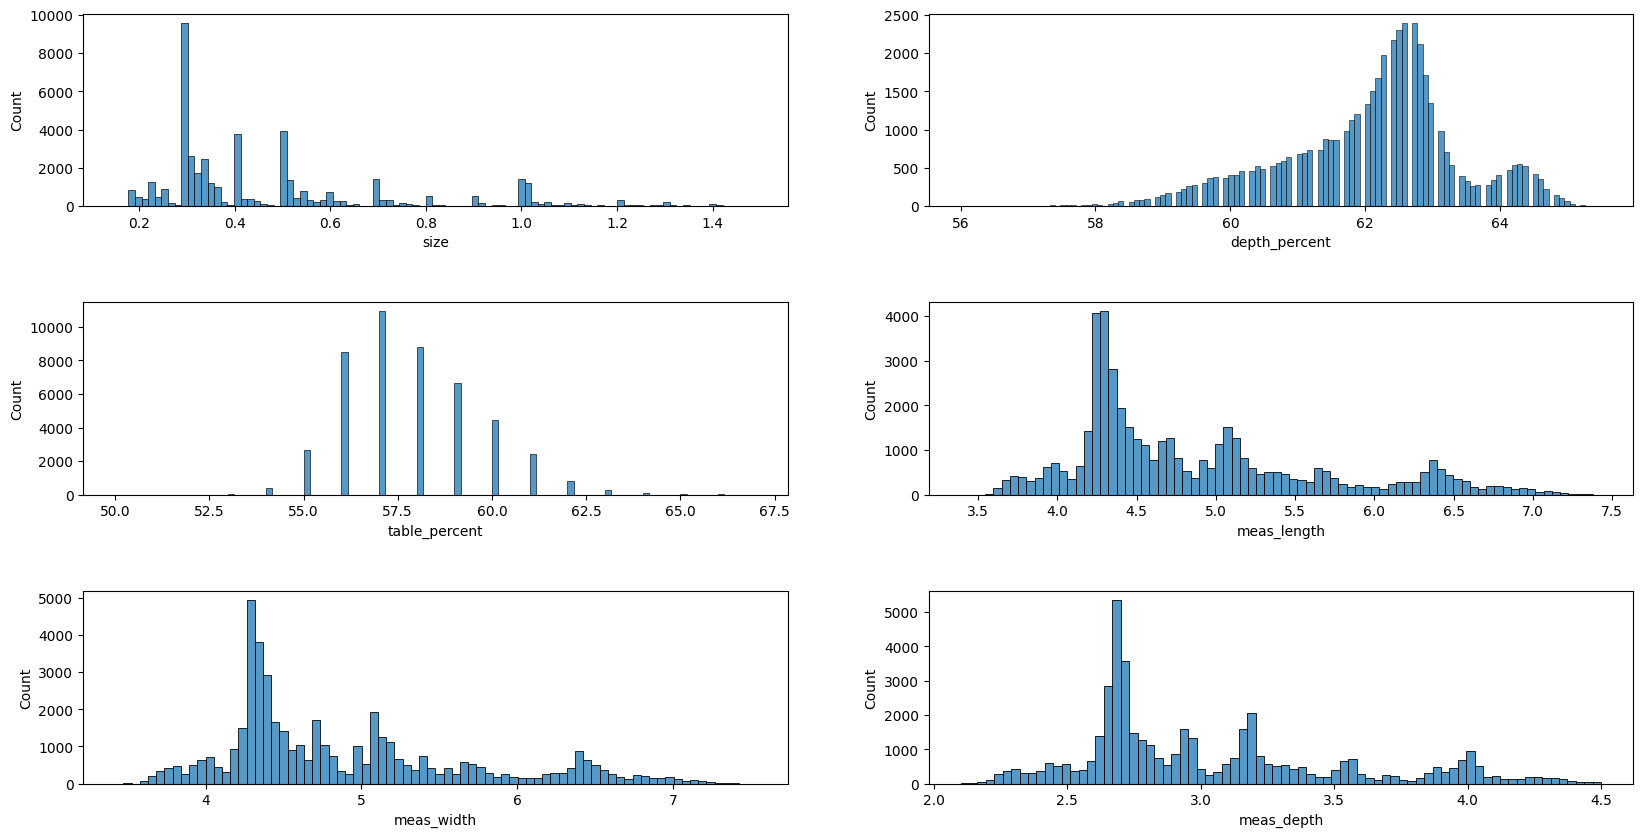

In [47]:
list_columns_number = X_train.select_dtypes(include=['number']).columns.values
display(list_columns_number)

fig, ax = plt.subplots(3, 2, figsize = (20,10))
plt.subplots_adjust(hspace=0.5)
for axi, name in zip(ax.flat, list_columns_number):
    sns.histplot(X_train, x=name, ax=axi) 

Все распределения скошенны вправо, есть несколько пиков, это связано с тем что есть некоторые стандартные размеры брильянтов. Также присутствуют выбросы

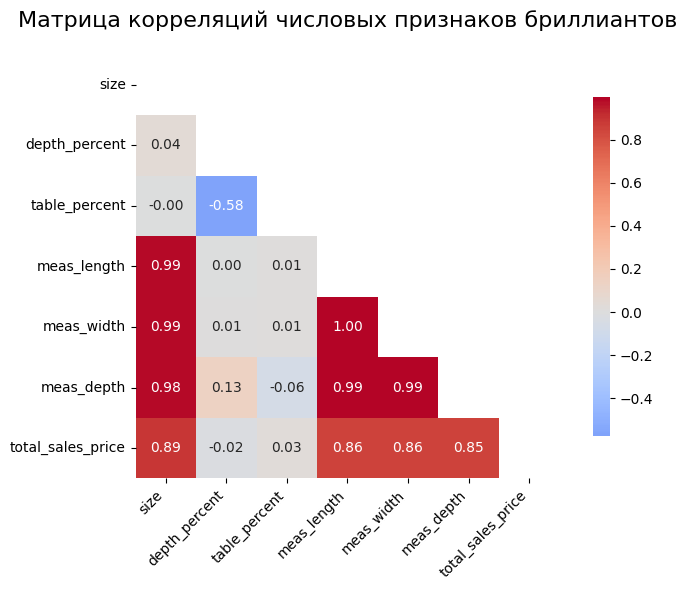

In [48]:
plt.figure(figsize=(8, 6))

corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляций числовых признаков бриллиантов', fontsize=16, pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Кореляция есть и не маленькая. Очевидно что длина, глубина и ширина коррелируют с размером. Также видна большая степень кореляции между размером и ценой брильянта, это хороший знак.

In [11]:
num = [ 'meas_length', 'meas_width', 'meas_depth']
cat = ['cut', 'symmetry', 'polish']  
poly_features = ['size', 'depth_percent', 'table_percent']
girdle_features = ['girdle_min', 'girdle_max']       
fluor_features = ['fluor_color', 'fluor_intensity']


**clarity** OrdinalEncoder используется потому, что признак "clarity" является порядковой категориальной переменной, это означает, что: категории имеют естественный порядок, одна категория лучше или хуже другой и между категориями существует иерархия.

In [12]:
clarity_map = [{
    'col':'clarity',
    'mapping':{'IF':9, 'VVS1':8, 'VVS2':7, 'VS1':6, 'VS2':5, 
               'SI1':4, 'SI2':3, 'I1':2, 'I2':1, 'I3':0}
    }]

clarity_transformer = Pipeline(steps=[
    ('ce',ce.OrdinalEncoder(mapping=clarity_map)),
    ('scaler', StandardScaler())
    ])    
 


**'size', 'depth_percent', 'table_percent'** чтобы учесть нелинейные зависимости и взаимодействие между признаками используем полиномиальный фичинг. Я не использовала полиномы для 'meas_length', 'meas_width', 'meas_depth' потому что они имеют сильную кореляцию с признаком 'size', а полиномы могут усугубить эту проблему.

In [13]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())  
])

**'girdle_min', 'girdle_max'** Слишком тонкий рундист хрупкий и может треснуть, слишком толстый - делает алмаз визуально меньше. Поэтому идеальна средняя толщина. То есть тут тоже есть иерархия которую хотелось бы обозначить поэтому использую OrdinalEncoder со своими метками, где M - самая оптимальная толщина, XTN - самый тонкий рундист (слишком тонкий рундист может приводить к сколам и это снижает цену брильянта), XTK - самый толстый рундист ( такой рундист прячет вес брильянта и брильянт выглядит меньше, соответственно и стоит намного меньше ).

In [14]:
girdle_min_map = [{
    'col': 'girdle_min',
    'mapping': {'M': 8,'STN': 7,'TN': 6,'STK': 5,'VTN': 4, 'XTN': 3,'TK': 2,'VTK': 1 }
}]

girdle_max_map = [{
    'col': 'girdle_max', 
    'mapping': { 'M': 8, 'STN': 7, 'TN': 6,'STK': 5, 'VTN': 4, 'XTN': 3, 'TK': 2, 'VTK': 1, 'XTK': 0 }
}]

girdle_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('encoder', ce.OrdinalEncoder(
        cols=['girdle_min', 'girdle_max'],
        mapping=girdle_min_map + girdle_max_map
    )),
    ('scaler', StandardScaler())
])

**'fluor_color', 'fluor_intensity'** Тут тоже есть иерархия, то есть чем больше флюорисценция тем дешевле стоит брильянт. Также флюрисценция желтого и оранжевого цвета может делать брильянт более желтым и мутным, что приводит к снижению цены. Синяя флюорисценция наоборот может слегка скорректировать желтизну брильянта, она тоже снижает стоимость, но в меньшей степени чем другие цвета. Лучший вариант это когда флюорисценции нет совсем, и будем считать что пропуски в данных означают отсутствие флюорисценции.


In [15]:
fluor_color_map = [{
    'col': 'fluor_color',
    'mapping': {
        np.nan: 5,    
        'Blue': 4,    
        'White': 3,   
        'Green': 2,
        'Yellow': 1,  
        'Orange': 0   
    }
}]

fluor_intensity_map = [{
    'col': 'fluor_intensity',
    'mapping': {
        np.nan: 5,          
        'Very Slight': 4,    
        'Faint': 3,          
        'Medium': 2,         
        'Strong': 1,         
        'Very Strong': 0     
    }
}]

fluor_pipeline = Pipeline([  
    ('encoder', ce.OrdinalEncoder(
        cols=['fluor_color', 'fluor_intensity'],
        mapping=fluor_color_map + fluor_intensity_map
    )),
    ('scaler', StandardScaler())
])

**'color'** Тут я пронумеровала цвета от лучшего к худшему, то есть от бесцветного к желтому, так как бесцветные стоят дороже.

In [16]:
color_map = [{
    'col': 'color',
    'mapping': {
        'D': 9,  
        'E': 8,   
        'F': 7,
        'G': 6,
        'H': 5,
        'I': 4,
        'J': 3,
        'K': 2,
        'L': 1,
        'M': 0   
    }
}]


color_pipeline = Pipeline([
    ('encoder', ce.OrdinalEncoder(mapping=color_map)),
    ('scaler', StandardScaler())
])


**eye_clean** тут пронумеровоны степени видимости вкючений, то есть 'Yes' - чистый глаз и включения не видны и это лучший вариант, который повышает цену. 'No' - худший вариант, снижает цену.

In [17]:
eye_clean_map = [{
    'col': 'eye_clean',
    'mapping': {
        'No': 0,          
        'E1': 1,  
        'Borderline': 2,  
        'Yes': 3           
    }
}]


eye_clean_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', ce.OrdinalEncoder(mapping=eye_clean_map)),
    ('scaler', StandardScaler())
])

In [18]:

preprocessor = ColumnTransformer([
    ('num',  StandardScaler(), num),
    ('num_poly', poly_pipeline, poly_features),
    ('cat', OneHotEncoder(drop='first',sparse_output=False), cat),
    ("clarity", clarity_transformer, ['clarity']),
    ('fluor', fluor_pipeline, fluor_features),
    ('girdle', girdle_pipeline, girdle_features),
    ('color_imp', color_pipeline, ['color']),
    ('eye_cleaned', eye_clean_pipeline, ['eye_clean'])
]).set_output(transform='pandas')

display(preprocessor)

ct = preprocessor.fit_transform(X_train)
pd.DataFrame(ct).head()

,transformers,"[('num', ...), ('num_poly', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


,num__meas_length,num__meas_width,num__meas_depth,num_poly__size,num_poly__depth_percent,num_poly__table_percent,num_poly__size^2,num_poly__size depth_percent,num_poly__size table_percent,num_poly__depth_percent^2,...,cat__cut_Very Good,cat__symmetry_Very Good,cat__polish_Very Good,clarity__clarity,fluor__fluor_color,fluor__fluor_intensity,girdle__girdle_min,girdle__girdle_max,color_imp__color,eye_cleaned__eye_clean
25119,0.113131,0.110767,0.304203,0.071683,1.615274,-0.441301,-0.139568,0.135127,0.045263,1.640405,...,1.0,1.0,0.0,0.751282,0.292147,0.69153,0.578742,0.041938,0.032742,0.07676
7560,-0.717593,-0.714693,-0.739567,-0.690164,-0.230753,0.113165,-0.582181,-0.696203,-0.682814,-0.241886,...,0.0,0.0,0.0,-0.833387,0.292147,0.69153,0.578742,0.041938,0.032742,0.07676
1846,-0.277058,-0.264442,-0.257827,-0.385425,0.153836,-0.995767,-0.431693,-0.381450,-0.428315,0.144345,...,0.0,1.0,0.0,1.807728,0.292147,0.69153,0.578742,0.041938,0.878980,0.07676
27954,0.327105,0.323385,0.264058,0.109775,-0.461507,-0.995767,-0.111628,0.090066,0.049198,-0.472130,...,0.0,1.0,1.0,-0.833387,0.292147,0.69153,0.578742,0.041938,-0.390377,0.07676
27666,1.296283,1.286422,1.408190,1.214454,0.769178,-1.550233,0.939301,1.261958,1.061946,0.768787,...,0.0,0.0,0.0,-1.361610,0.292147,0.69153,0.578742,0.041938,0.455861,0.07676


In [19]:
missing_info = pd.DataFrame({
    'Пропуски': ct.isnull().sum(),
    'Процент пропусков': (ct.isnull().sum() / len(X_train) * 100).round(2)
})

print(missing_info)

                                       Пропуски  Процент пропусков
num__meas_length                              0                0.0
num__meas_width                               0                0.0
num__meas_depth                               0                0.0
num_poly__size                                0                0.0
num_poly__depth_percent                       0                0.0
num_poly__table_percent                       0                0.0
num_poly__size^2                              0                0.0
num_poly__size depth_percent                  0                0.0
num_poly__size table_percent                  0                0.0
num_poly__depth_percent^2                     0                0.0
num_poly__depth_percent table_percent         0                0.0
num_poly__table_percent^2                     0                0.0
cat__cut_Very Good                            0                0.0
cat__symmetry_Very Good                       0               

Отлично все пропуски заполнены.

График распределения цены.

<Axes: >

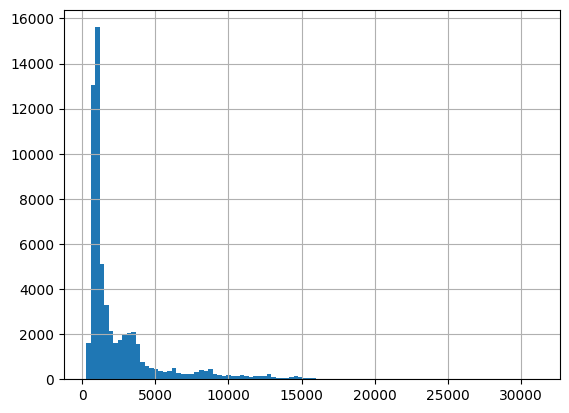

In [11]:
df['total_sales_price'].hist(bins=100)

По графику видно что распределение цены сильно скошено вправо, то есть данных о более дешёвых брильянтов сильно больше чем о дорогих, значит и  разброс ошибок для дорогих алмазов может быть значительно выше, чем для дешевых. В таком случае ошибки модели также имеют скошенное распределение, что приводит к неэффективности и смещенности оценок коэффициентов модели. Эту проблему можно исправить с помощью преобразования данных к нормальному распределению.

Протестируем основные модели.

In [26]:
model_target =  TransformedTargetRegressor(
                regressor = Pipeline(steps=[
                                ('preproc',  preprocessor),
                                ('estimator', KNeighborsRegressor())
                            ]),
                transformer=QuantileTransformer(n_quantiles=1000, output_distribution="normal")
)

model_target.fit(X_train, y_train)
y_pred_test = model_target.predict(X_test)

In [27]:
msle = mean_squared_log_error(y_test, y_pred_test)
msle

0.02187684435320881

In [28]:
model_target =  TransformedTargetRegressor(
                regressor = Pipeline(steps=[
                                ('preproc',  preprocessor),
                                ('estimator', Ridge())
                            ]),
                transformer=QuantileTransformer(n_quantiles=1000, output_distribution="normal")
)

model_target.fit(X_train, y_train)
y_pred_test = model_target.predict(X_test)

In [29]:
msle = mean_squared_log_error(y_test, y_pred_test)
msle

0.04464071151005068

In [30]:
pipe_best =  TransformedTargetRegressor(
                regressor = Pipeline(steps=[
                                ('preproc',  preprocessor),
                                ('estimator', SVR())
                            ]),
                transformer=QuantileTransformer(n_quantiles=1000, output_distribution="normal")
)

pipe_best.fit(X_train, y_train)
y_pred_test_best = pipe_best.predict(X_test)

In [31]:
msle = mean_squared_log_error(y_test, y_pred_test_best)
msle

0.0099895851743776

In [32]:
def plot_2_error_msle(y_true, y_predicted):
    residuals = np.log1p(y_true) - np.log1p(y_predicted)
    
    max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)
    max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(residuals).index(min(residuals))
    max_true, max_pred = y_true[max_idx], y_predicted[max_idx]
    msle = mean_squared_log_error(y_true, y_predicted)
    
    print("Max Log Error:", "{:,.4f}".format(max_error))
    print(' ')
    print('----------------------')
    print("   MSLE:", "{:,.6f}".format(msle))
    print('----------------------')

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
    from statsmodels.graphics.api import abline_plot
    
    ax[0].scatter(np.log1p(y_predicted), np.log1p(y_true), color="black", alpha=0.25)
    abline_plot(intercept=0, slope=1, color="red", ax=ax[0])
    ax[0].vlines(x=np.log1p(max_pred), ymin=np.log1p(max_true), ymax=np.log1p(max_true)-max_error, 
                 color='red', linestyle='--', alpha=0.7, label="max error")
    ax[0].grid(True)
    ax[0].set(xlabel="log(1 + Predicted)", ylabel="log(1 + True)", title="Predicted vs True (Log Scale)")
    ax[0].legend()

    ax[1].scatter(np.log1p(y_predicted), residuals, color="red", alpha=0.25)
    ax[1].vlines(x=np.log1p(max_pred), ymin=0, ymax=max_error, color='black', linestyle='--', alpha=0.7, label="max error")
    ax[1].grid(True)
    ax[1].set(xlabel="log(1 + Predicted)", ylabel="Log Residuals", title="Predicted vs Log Residuals")
    ax[1].hlines(y=0, xmin=np.min(np.log1p(y_predicted)), xmax=np.max(np.log1p(y_predicted)))
    ax[1].legend()
    plt.show()

Max Log Error: 1.0236
 
----------------------
   MSLE: 0.009990
----------------------


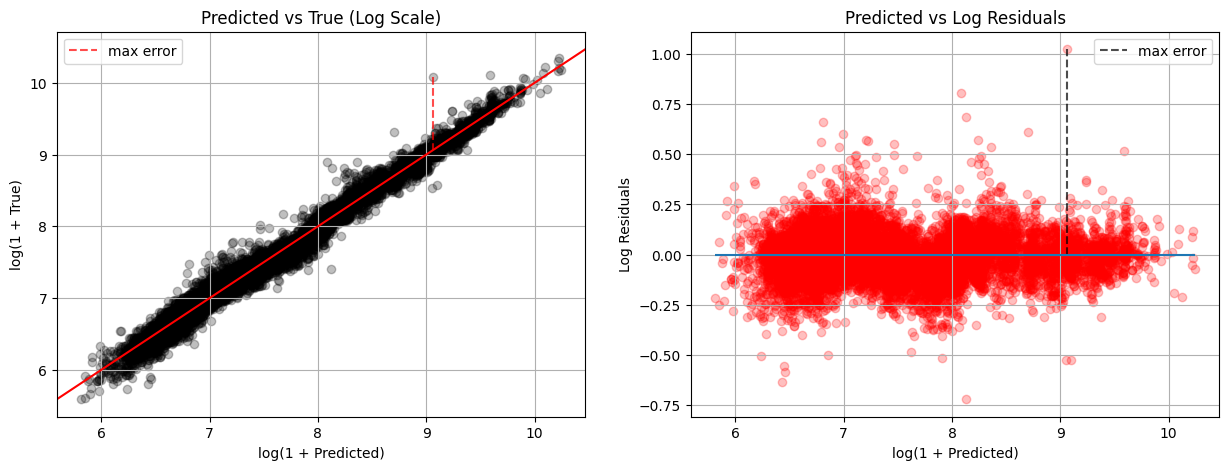

In [33]:
plot_2_error_msle(y_test, y_pred_test_best)

SVR дал лучший результат, оценка модели хорошая, графики красивые поэтому берем его.

Я пыталась подбирать параметры моделей на сетках, но это не улучшило результат, поэтому берем базовую модель.